In [ ]:
import re
import uuid
from datetime import datetime
import json
from tqdm import tqdm
tqdm.pandas()

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

import sys
sys.path.append('../backend/app')

from database.connection import db

from typing import Annotated, Literal, List, Any
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from operator import add

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.runnables import RunnableConfig

from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END

from langgraph.checkpoint.memory import MemorySaver

from dotenv import load_dotenv
load_dotenv()

True

## Text to SQL
* 결과가 없을 때, humman in the loop
    * 언제 검사할 것인지
    * 어떻게 확인할 것인지
* user_id를 통해 user가 가져올 수 있는 정보의 범위 제한
    * 언제 검사할 것인지
    * 어떻게 확인할 것인지

In [ ]:
class SqlState(TypedDict):
    origin_query: Annotated[str, "origin user query"]
    user_id: Annotated[str, "User ID"]
    
    rewritten_query: Annotated[List[str], add]
    errors: Annotated[List[str], add]
    sql: Annotated[List[str], add]
    
    selected_data: List[Any]
    final_answer: str

    cancelled: bool
    error_num: int
    direction: str

    only_data: bool

### 1. DB 스키마 

In [5]:
schema = """
[Notice]
This is the schema of all available tables in the database.
Please proceed with your task based on the schema below.

[Schema]
{{
"tables": {{
    "pose_scores": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "session_id": "int, foreign key → pose_evaluation_sessions.id",
            "connection_index": "varchar(100), not null, example: '11-12'",
            "user_score": "decimal(10,4), not null",
            "status": "enum('achieved','warning','below_standard'), default 'achieved'"
        }}
    }},
    "sport_standard_scores": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "video_id": "int, foreign key → videos.id",
            "connection_index": "varchar(100), not null, example: '11-12'",
            "connection_name": "varchar(100), not null, example: '왼쪽엉덩이-오른쪽엉덩이'",
            "standard_score": "decimal(5,2), not null"
        }}
    }},
    "pose_evaluation_sessions": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "user_id": "int, foreign key → users.id",
            "sport_id": "int, foreign key → sports.id",
            "user_video_id": "int, foreign key → videos.id",
            "standard_video_id": "int, foreign key → videos.id",
            "created_at": "timestamp, default CURRENT_TIMESTAMP"
        }}
    }},
    "sports": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "name": "enum('인상', '용상')",
        }}
    }}
}},
"relationships": [
    {{"from": "pose_scores.session_id", "to": "pose_evaluation_sessions.id"}},
    {{"from": "pose_evaluation_sessions.sport_id", "to": "sports.id"}},
    {{"from": "sport_standard_scores.video_id", "to": "videos.id"}}
    ]
}}
"""

### 2. Synonym(동의어 처리)

In [6]:
def synonum_process(state: SqlState):
    origin_query = state['origin_query'].lower()

    synonym_map = {
        "snatch": "용상",
        "snatch lift": "용상",
        "스내치": "용상",
        "스네치": "용상",
        "스냇치": "용상",

        "clean and jerk": "인상",
        "clean&jerk": "인상",
        "clean & jerk": "인상",
        "clean n jerk": "인상",
        "클린 앤드 저크": "인상",
        "클린 엔드 저크": "인상",
        "클린 앤 저크": "인상",
        "클린 엔 저크": "인상",
        "클린엔저크": "인상",
        "클린앤저크": "인상",
        "클린엔드저크": "인상",
        "클린앤드저크": "인상",
        "clean n jerk": "인상",
        }

    rewritten_query = origin_query

    # 동의어 매칭 및 변환
    for synonym, standard in synonym_map.items():
        if synonym in rewritten_query:
            rewritten_query = rewritten_query.replace(synonym, standard)

    return {"rewritten_query": [rewritten_query]}

### 3. Text to SQL을 위한 query rewrite
- 목적: 자연어로 입력된 사용자의 질의를 DB에서 쉽게 사용할 수 있는 명확하고 일관된 질의문으로 변환하기 위한 프롬프트 설계.

- 이 프롬프트의 핵심 규칙 요약:
    1. 시간 표준화(Temporal Standardization)
        - "어제", "저번 주" 등과 같은 상대적 시간 표현을 절대적인 날짜 혹은 기간으로 명확하게 변환한다.
        - 예: "어제" → "2025-11-05" (현재 컨텍스트 날짜 기준)
    2. 동작명 표준화(Exercise Standardization)
        - 비표준적인 운동/동작명은 Exercise Map에서 매핑된 표준 한글명으로 치환한다.
        - 예: "클린 엔 저크", "clean and jerk" → "인상"
    3. 신체 부위 명확화 및 추상 그룹 해체(Body Part Standardization & Grouping)
        - "하체", "상체", "팔" 등과 같이 추상적 신체 그룹 표현이 등장하면, 해당 그룹에 포함된 Keypoint Connection Names의 구체 목록을 명시적으로 질의문에 제시한다.
        - 예: "하체" → ["왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎", "왼쪽무릎-왼쪽발목", "오른쪽무릎-오른쪽발목"]
    4. 명확성과 독립성(Clarity)
        - 재작성된 질의는 Text-to-SQL Agent로 바로 전달되어도 될 만큼, 독립적이고 모호성이 없도록 충분한 정보를 담고 있어야 한다.

- 예시
    - 입력: "어제 영상에서 하체 부위의 점수는 몇 점이야?"
    - 최종 재작성: "2025-10-01 영상에서 '왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎', '왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목' 부위의 평균 점수를 조회."
- 프롬프트 입력 주의점
    - 신체부위와 관련해 "~~ 부위"와 "~~에서" 입력 시 차이가 발생
        - "골반에서" -> "왼쪽엉덩이-오른쪽엉덩어"
        - "골반 부위에서" -> "왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎"

In [7]:
class QueryRewriteSQL(BaseModel):
    """ Schema for the rewritten user query to enhance downstream DB querying. """
    rewritten_query: str = Field(
        ...,
        description="A string that rewrites the natural language query into a DB-friendly format."
    )

queryRewrite_parser = PydanticOutputParser(pydantic_object=QueryRewriteSQL)

In [52]:
rewriteSql_template = """
[SYSTEM ROLE]
You are the Query Rewriter Agent. Your sole task is to rewrite the user's natural language query into a clear, unambiguous, and DB-friendly format. This rewritten query will be passed directly to the Text-to-SQL Agent. You MUST first think carefully and slowly, following all the rules provided.

[REWRITING RULES]
1. Temporal Standardization: Resolve all relative time expressions (e.g., "어제", "저번 주") into absolute date ranges or specific dates using the provided Current Datetime.
2. Exercise Standardization: Replace all non-standard exercise names with the standardized Korean names from the Exercise Map.
3. Body Part Standardization & Grouping:
    *   If the user mentions an abstract group (e.g., "종아리", "팔뚝", "몸통"), you must infer the corresponding list of Keypoint Connection Names (e.g., "왼쪽어깨-왼쪽팔꿈치") and include them in the rewritten query.
    *   The rewritten query must explicitly list the Keypoint Connection Names instead of the abstract group name.
4. Clarity: The final rewritten query must be a clear, self-contained instruction for the Text-to-SQL Agent, containing all standardized information.


[CONTEXT]
- Current Datetime: {current_datetime}
- Exercise Map: {{
    "클린 엔 저크": "인상",
    "clean and jerk": "인상",
    "cl&jk": "인상",
    ...
    "인상": "인상",
    "스내치": "용상",
    "snatch": "용상",
    "sna": "용상",
    ...
    "용상": "용상",
    }}
- Keypoint Connection Names: [
    "왼쪽어깨-오른쪽어깨", "왼쪽어깨-왼쪽팔꿈치", "왼쪽어깨-왼쪽엉덩이",
     오른쪽어깨-오른쪽팔꿈치", "오른쪽어깨-오른쪽엉덩이",
    "왼쪽팔꿈치-왼쪽손목", "오른쪽팔꿈치-오른쪽손목", 
    "왼쪽엉덩이-오른쪽엉덩이", "왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎", 
    "왼쪽무릎-왼쪽발목", "오른쪽무릎-오른쪽발목"
    ]

[OUTPUT FORMAT]
{format}

[FEW-SHOT EXAMPLES]

Example 1 (Temporal & Exercise Standardization & Abstract Groupting - 허리)
User Query: "오늘 올린 snach 영상의 허리 관련 점수를 알려줘."
Draft (CoT):
1. Temporal: "오늘" -> {current_datetime}.
2. Exercise: "snach" -> "용상".
3. grouping: "허리" is an abstract group. Infer Keypoint Connection Names: 허리('왼쪽어깨-왼쪽엉덩이', '오른쪽어깨-오른쪽엉덩이').
4. Rewrite: {current_datetime}에 업로드된 용상 영상의 '왼쪽어깨-왼쪽엉덩이', '오른쪽어깨-오른쪽엉덩이' 부위의 점수를 조회."

Example 2 (Excercise Standardization & Abstract Groupting - 다리)
User Query: "clean&jerk 영상에서 종아리 부위 점수의 동향을 알려줘.
Draft (CoT):
1. Exercise: "clean&jerk" -> "인상"
2. Grouping: "종아리" is an abstract group. Infer Keypoint Connection Names: 팔('왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목').
3. Rewrite: 인상 영상에서 '왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목' 부위의 점수 동향을 조회.

[USER QUERY]
{user_query}
"""

In [ ]:
system_prompt = schema + '\n' + rewriteSql_template

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt)
])

prompt = prompt.partial(format=queryRewrite_parser.get_format_instructions())

rewrite_sql_chain = prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [54]:
def query_rewrite_sql(state: SqlState) -> dict[str, list[AIMessage]]:
    """
    This stage transforms the input message to fit the database schema before converting it to SQL.
    """
    input_query = state['rewritten_query'][-1]
    rewritten_query = rewrite_sql_chain.invoke({"user_query": input_query, 
                                                "current_datetime": datetime.now().strftime('%Y-%m-%d')})
    rewritten_query = queryRewrite_parser.parse(rewritten_query.content).rewritten_query
    
    return {
        "rewritten_query": [rewritten_query]
    }

### 4. Query_Generate

In [31]:
query_gen_instruction = """
[SYSTEM ROLE]
You are a Text-to-SQL expert specializing in converting user questions into MySQL queries. Your sole objective is to generate a syntactically correct and accurate SELECT query based on the provided information. Think carefully and slowly.

[INPUT CONTEXT]
You must use the following information to generate the query:
1.  **User Question (Natural Language):** The original question the user is asking about the database.
2.  **Database Schema:** The structural information of the target database.
3.  **Error History:** A list of error messages from previously executed queries. You must use this information to correct your query and avoid repeating the same mistakes. (This list may be empty if there were no prior errors).
4.  **User ID:** The ID of the user making the request. This must be used for data filtering.

[QUERY GENERATION RULES]
1.  **Objective:** Your only output must be a MySQL query statement. Do not include any other text, explanations, or prefixes.
2.  **Safety:** You must NEVER generate DML (Data Manipulation Language) statements such as INSERT, UPDATE, DELETE, or DROP. Only **SELECT** statements are permitted.
3.  **Mandatory Security Filter:** When querying the `pose_evaluation_sessions` table, you **MUST** include a filter in the WHERE clause using the provided **User ID** (e.g., `pose_evaluation_sessions.user_id = {user_id}`). This is a non-negotiable security requirement.
4.  **Accuracy:** Carefully analyze the schema to use only existing table and column names, and establish correct JOIN relationships to generate an accurate query.
5.  **Error Correction:** If an 'Error History' is provided, you must analyze the cause of the error and generate a new query that resolves it.

[OUTPUT FORMAT]
- Output ONLY the SQL query statement (no prefix, no explanation).
- Do not prepend or append any other text, explanations, comments, quotation marks, or code block markdowns (e.g., ` ```sql `).

[EXAMPLE OUTPUT]
   'SELECT 
      s.connection_name,
      ps.user_score,
      ps.status
   FROM pose_scores AS ps
   JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
   JOIN sports AS sp ON ses.sport_id = sp.id
   JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
   JOIN videos AS v ON ses.user_video_id = v.id
   WHERE ses.user_id = 1
   AND sp.name = '인상'
   AND DATE(v.created_at) = '2025-11-09'
   AND s.connection_name IN ('왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎');'
"""

In [ ]:
system_prompt = schema + '\n' + query_gen_instruction

query_gen_prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt), 
     ("placeholder", "{errors}"), 
     ("user", "user_id: {user_id}\nuser_question: {user_question}")]
)

query_gen = query_gen_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)

In [33]:
def query_gen_node(state: SqlState):
    message = query_gen.invoke({"errors": state['errors'],
                                "user_id": state['user_id'],
                                "user_question": state["rewritten_query"][-1]})    
    
    return {"sql": [message.content]}

### 5. Query_Check
* sql_query_gen에서 생성된 sql문의 검증 과정
* 생성된 sql의 user_id에 대한 기계적 검증, 개인정보 보호를 위한

In [ ]:
def validate_generated_sql(state: SqlState):
    """
    Validate SQL generated by the Text-to-SQL system.

    Checks:
    1. Query must be SELECT-only.
    2. If 'pose_evaluation_sessions' is referenced, query MUST contain 
       a WHERE clause filtering by pose_evaluation_sessions.user_id = {user_id}
       or via its alias (e.g., ses.user_id = {user_id}).
    """
    sql = state['sql'][-1]
    user_id = str(state['user_id'])
    error_num = state['error_num']

    errors = []

    normalized_sql = sql.lower().replace("\n", " ")
    normalized_sql = re.sub(r'\s+', ' ', normalized_sql.strip().lower())

    # --- Rule 1: Only SELECT allowed ---
    if not normalized_sql.startswith("select"):
        actual_start = normalized_sql[:10]
        errors.append(f"Query must start with SELECT. Query begins with: '{actual_start}'.")

    forbidden = ["insert", "update", "delete", "drop", "truncate", "alter"]
    if any(word in normalized_sql for word in forbidden):
        errors.append("DML/DDL statements are not allowed.")
    
    # --- Rule 2: alias-aware user filter enforcement ---
    using_pose_sessions = "pose_evaluation_sessions" in normalized_sql

    if using_pose_sessions:
        # 1) alias 추출: "pose_evaluation_sessions as ses" 또는 "pose_evaluation_sessions ses"
        alias_pattern = r"pose_evaluation_sessions\s+(as\s+)?(\w+)"
        alias_match = re.search(alias_pattern, normalized_sql)

        aliases_to_check = []

        if alias_match:
            alias = alias_match.group(2)
            aliases_to_check.append(alias)

        # 풀네임도 검사
        aliases_to_check.append("pose_evaluation_sessions")

        # 2) 각 alias에 대해 user_id 필터 여부 검사
        filter_found = False
        for alias in aliases_to_check:
            pattern = rf"{alias}\.user_id\s*=\s*{user_id}"
            if re.search(pattern, normalized_sql):
                filter_found = True
                break

        if not filter_found:
            errors.append(
                f"Missing required security filter: pose_evaluation_sessions.user_id = {user_id} "
                f"(alias allowed: e.g., ses.user_id = {user_id})."
            )

        # WHERE 절 존재 여부
        if " where " not in normalized_sql:
            errors.append("Query uses pose_evaluation_sessions but has no WHERE clause.")
    
    if errors != []:
        error_num += 1
        
        if error_num >= 3:
            return {"direction": 'human_in_the_loop', "error_num": error_num}
        
        errors = 'Error:' + '\n'.join(errors)
        return {"direction": "query_generate",
                "errors": [errors],
                "error_num": error_num}

    return {"direction": "execute_query"}

In [35]:
def should_continue_check(state: SqlState) -> Literal["query_generate", "execute_query", "human_in_the_loop"]:
    """
    validation_check 노드에서 나온 결과를 기반으로 다음 노드를 결정.
    """    
    return state.get("direction", "query_generate")

### 6. Execute_Query

In [ ]:
def execute_query_node(state: SqlState):
    query = state['sql'][-1]

    result = db.execute_query(query, structured = True)

    if not result['success']:
        message = f"Error: {result['error']}"
        error_num = state['error_num'] + 1

        if (error_num >= 3):
            return {"error_num": error_num,
                    "errors": [message],
                    "direction": "human_in_the_loop"}
        
        return {"direction": "query_generate",
                "error_num": error_num,
                "errors": [message]}

    elif (result['success'] == True) and (result['data'] == []):
        return {"direction": "human_in_the_loop"}
    
    else:
        data_str = json.dumps(result['data'], default=str, ensure_ascii=False)
        
        if state['only_data'] == True:
            return {"selected_data": [data_str],
                    "final_answer": data_str,
                    "diriction": END}
        
        return {"selected_data": [data_str],
                "direction": "final_answer"}

In [ ]:
def should_continue_execute(state: SqlState) -> Literal["query_generate", "final_answer", "human_in_the_loop", END]:
    return state['direction']

### 5. Final_Answer

In [ ]:
final_answer_instruction = """
[SYSTEM ROLE]
You are a data analyst and communication specialist. Your mission is to generate a clear and natural language answer to the user's original question based on the provided query results.

[INPUT CONTEXT]
You must use the following information to generate the answer:
1. **User Question:** The original question the user asked, to understand their intent.
2. **Query Result:** The actual data retrieved from the database. This data may be in JSON, CSV, or a similar structured format.

[RESPONSE GENERATION RULES]
1. **Result-Driven Answer:** If the 'Query Result' contains data, you must interpret that data to generate a direct answer to the 'User Question'.
2. **Natural Language:** Instead of presenting raw data, you must process it into a complete, human-readable sentence.
3. **Focus on the Core Question:** Identify the core of the user's question and structure your answer around that information. Omit unnecessary details to keep the response concise.

[OUTPUT FORMAT]
- Output only the final answer in a natural sentence.
- Do not add prefixes like "Answer:" to your response.
"""

In [39]:
final_answer_prompt = ChatPromptTemplate.from_messages(
    [("system", final_answer_instruction),
     ("placeholder", "{query_result}"),
     ("user", "user_id: {user_id}\nuser_question: {user_question}")]
)

final_gen = final_answer_prompt | ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [40]:
def final_answer_node(state:SqlState):
    answer = final_gen.invoke({"query_result": state['selected_data'],
                               "user_id": state['user_id'],
                               "user_question": state["rewritten_query"][-1]})

    return {'final_answer': answer.content}

### 6. Human In The Loop
* query_generate에서 빈 리스트([]) 값이 반환될 경우, 유저로부터 query를 재입력 받는 단계
* 재입력을 위한 db 내 user의 종합 테이블 출력
* 종합 테이블에서 직접 값을 선택하는 방법도 고려

In [41]:
import httpx  # pip install httpx

def get_all_score_history_sync(user_id: str):
    """
    API 엔드포인트를 동기적으로 호출하는 래퍼 함수
    """
    try:
        # API 엔드포인트 URL (자신의 서버 주소로 변경)
        url = f"http://localhost:8000/api/score/all_score_history?user_id={user_id}"        
        # 동기 HTTP 요청
        response = httpx.get(url, timeout=10.0)
        response.raise_for_status()  # 에러 체크
        
        return response.json()
    except Exception as e:
        print(f"점수 기록 조회 실패: {str(e)}")
        return []

In [ ]:
def human_in_the_loop(state: SqlState):
    """Human-in-the-loop 노드: 사용자 개입이 필요한 경우 호출됩니다."""
    
    score_history = get_all_score_history_sync(state["user_id"])
    serialized_data = json.loads(json.dumps(score_history, default=str))

    user_response = interrupt({
        "rewritten_query": state["rewritten_query"][-1],
        "user_data": serialized_data
    })

    if user_response.get('cancelled') == True:
        cancel_message = "User cancelled the entire process."
        return {
            "cancelled": True,
            "final_answer": cancel_message,
            "direction": END
        }
    if user_response.get('selected_data') != []:
        if state['only_data'] == True:
            return {
                "selected_data": user_response.get("selected_data"), # 나중에 list, json을 string으로 변환 유무를 확인해야 함.
                "final_answer": user_response.get("selected_data"),
                "direction": END
            }
        
        return {
            "selected_data": user_response.get("selected_data"),
            "direction": "final_answer"

        }
    if user_response.get('user_input') != '':
        user_input = user_response["user_input"]
        
        return {
            "rewritten_query": [user_input],
            "direction": "query_generate"
        }

In [43]:
def should_continue_hitl(state: SqlState) -> Literal["query_generate", "final_answer", END]:
    return state["direction"]  

### 7. 워크플로우

In [ ]:
workflow = StateGraph(SqlState)

workflow.add_node("synonum_process", synonum_process)
workflow.add_node("sql_query_rewrite", query_rewrite_sql)
workflow.add_node("query_generate", query_gen_node)
workflow.add_node("validate_generated_sql", validate_generated_sql)
workflow.add_node("execute_query", execute_query_node)
workflow.add_node('human_in_the_loop', human_in_the_loop)
workflow.add_node("final_answer", final_answer_node)

workflow.add_edge(START, "synonum_process")
workflow.add_edge("synonum_process", "sql_query_rewrite")
workflow.add_edge("sql_query_rewrite", "query_generate")
workflow.add_edge("query_generate", "validate_generated_sql")
# workflow.add_edge("validate_generated_sql", "execute_query")


workflow.add_conditional_edges(
    "validate_generated_sql",
    should_continue_check,
    {
        "query_generate": "query_generate",
        "execute_query": "execute_query",
        "human_in_the_loop": "human_in_the_loop"
    }
)

workflow.add_conditional_edges(
    "execute_query",
    should_continue_execute,
    {
        "final_answer": "final_answer",
        "query_generate": "query_generate",
        "human_in_the_loop": "human_in_the_loop",
        END: END
    }
)

workflow.add_conditional_edges(
    "human_in_the_loop",
    should_continue_hitl,
    {
        "final_answer": "final_answer",
        "query_generate": "query_generate",
        END: END
    }
)

workflow.add_edge("final_answer", END)

app = workflow.compile(checkpointer=MemorySaver())


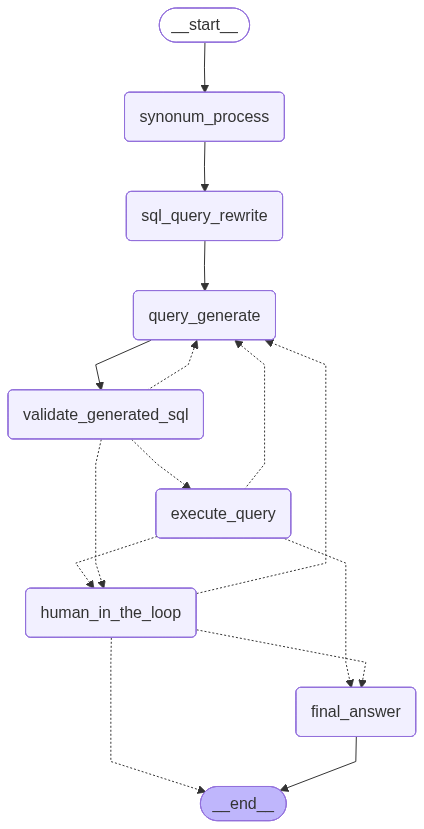

In [66]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [67]:
thread_id = '1'
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": thread_id}
)

inputs = SqlState({
    "origin_query": "user 2가 가장 최근에 올린 클린 엔 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.",
    "user_id": '1',
    "error_num": 0
    })

for step in app.stream(inputs, config):
    print(step)

{'synonum_process': {'rewritten_query': ['user 2가 가장 최근에 올린 인상 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.']}}
{'sql_query_rewrite': {'rewritten_query': ["user 2가 가장 최근에 올린 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회."]}}
{'query_generate': {'sql': ["SELECT \n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN videos AS v ON ses.user_video_id = v.id\nWHERE ses.user_id = 2\nAND sp.name = '인상'\nAND ps.connection_index IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')\nORDER BY ps.user_score ASC\nLIMIT 1;"]}}
{'validate_generated_sql': {'direction': 'query_generate', 'errors': ['Error:Missing required security filter: pose_evaluation_sessions.user_id = 1 (alias allowed: e.g., ses.user_id = 1).'], 'error_num': 1}}
{'query_generate': {'sql': ["SELECT \n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.ses

In [26]:
thread_id = '1'
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": thread_id}
)

inputs = SqlState({
    "origin_query": "가장 최근에 올린 클린 엔 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.",
    "user_id": '1',
    "error_num": 0
    })

for step in app.stream(inputs, config):
    print(step)

{'synonum_process': {'rewritten_query': ['가장 최근에 올린 인상 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.']}}
{'sql_query_rewrite': {'rewritten_query': ["가장 최근에 업로드된 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회."]}}
{'query_generate': {'sql': ["SELECT \n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nJOIN videos AS v ON ses.user_video_id = v.id\nWHERE ses.user_id = 1\nAND sp.name = '인상'\nAND v.id = (SELECT id FROM videos ORDER BY created_at DESC LIMIT 1)\nAND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')\nORDER BY ps.user_score ASC\nLIMIT 1;"]}}
{'validate_generated_sql': {'direction': 'execute_query'}}
{'execute_query': {'selected_data': ['[{"user_score": "95.4100", "status": "achieved"}]'], 'direction': 'final_answer'}}
{'final_answer': {'final_answer': "가장 최근에

In [51]:
# 최종 답변할 때, rewritten_query[-1]의 값도 같이 보여줘야 한다.

thread_id = '2'
config = RunnableConfig(
    recursion_limit=15, configurable={"thread_id": thread_id}
)

inputs = SqlState({
    "origin_query": "snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.",
    "user_id": '1',
    "error_num": 0
    })
    
for step in app.stream(inputs, config):
    print(step)

{'synonum_process': {'rewritten_query': ['용상 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.']}}
{'sql_query_rewrite': {'rewritten_query': ["용상 영상의 분석 결과에서 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수의 점수 동향을 조회."]}}
{'query_generate': {'sql': ["SELECT \n   ps.user_score,\n   ps.status,\n   ses.created_at\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nWHERE ses.user_id = 1\nAND sp.name = '용상'\nAND s.connection_name = '왼쪽엉덩이-오른쪽엉덩이';"]}}
{'validate_generated_sql': {'direction': 'execute_query'}}
{'execute_query': {'direction': 'human_in_the_loop'}}
{'__interrupt__': (Interrupt(value={'rewritten_query': "용상 영상의 분석 결과에서 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수의 점수 동향을 조회.", 'user_data': [{'user_id': 1, 'sport_name': '인상', 'created_at': '2025-10-24T03:00:46', 'connection_name': '왼쪽어깨-오른쪽어깨', 'standard_score': 83.58, 'user_score': 96.42, 'status': 'achieved'}, {'user_id': 1, 'sport_name':

In [ ]:
thread_id = '3'
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": thread_id}
)

inputs = {
    "origin_query": "가장 최근에 올린 snatch 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.",
    "user_id": '1'
    }

result = app.invoke(inputs, config)
# for step in app.stream(inputs, config):
#     if "rewritten_query" in step and step["rewritten_query"]:
#         for msg in step["rewritten_query"]:
#             print(f"[rewritten_query]\n{msg.content}\n\n")

#     for key, val in step.items():
#         if isinstance(val, dict) and "messages" in val:            
#             for msg in val["messages"]:
#                 print(f"[{key}]\n{msg.content}\n\n")

In [117]:
result['messages']

[AIMessage(content="가장 최근에 업로드된 용상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='0bef11da-0915-4254-87c0-922e65a1d2d9'),
 AIMessage(content="SELECT \n    s.connection_name,\n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nJOIN videos AS v ON ses.user_video_id = v.id\nWHERE ses.user_id = 1\nAND sp.name = '용상'\nAND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')\nORDER BY ps.user_score ASC\nLIMIT 1;", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 1194, 'total_tokens': 1345, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio

In [ ]:
inputs = {
    "origin_query": "가장 최근에 올린 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치'에서 가장 낮은 점수를 조회해줘.",
    "user_id": '1'
    }

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

SQL QUERY
```sql
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;
```
Answer: 가장 최근에 업로드된 인상 영상의 분석 결과에서 '오른쪽어깨-오른쪽팔꿈치' 부위의 점수는 82.3700이며, 상태는 'warning'입니다.


{'origin_query': HumanMessage(content="가장 최근에 올린 인상상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치'에서 가장 낮은 점수를 조회해줘.", additional_kwargs={}, response_metadata={}),
 'rewritten_query': [AIMessage(content="가장 최근에 업로드된 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='013e97c4-cc60-4304-afd7-3b2f45d60ffd')],
 'user_id': '1',
 'messages': [AIMessage(content="[Query Rewritten] 가장 최근에 업로드된 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='27f9d701-d76c-4e2a-94ee-2aa734e8fb58'),
  AIMessage(content="SQL QUERY\n```sql\nSELECT \n    s.connection_name,\n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nJOIN videos AS v ON ses.user_video_id = v.id\n

In [ ]:
# 
config = RunnableConfig(
    recursion_limit=15, configurable={"thread_id": uuid.uuid4()}
)

inputs = {
    "origin_query": "가장 최근에 올린 clean and 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.",
    "user_id": '2'
}

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

[sql_query_rewrite]
[Query Rewritten] 가장 최근에 업로드된 인상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 2
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;


[model_check]



[execute_query]
No Result: there is no result.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHER

In [ ]:
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": uuid.uuid4()}
)

inputs = {
    "origin_query": "snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.",
    "user_id": 2
    }

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

c:\Users\owner\anaconda3\envs\SportAgent\Lib\concurrent\futures\_base.py:161: RuntimeWarning: coroutine 'get_all_score_history' was never awaited
  pending_count = sum(


------query_rewrite------
용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.
------------------------------
------db_query_tool------
[]
------------------------------
{'origin_query': HumanMessage(content='snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.', additional_kwargs={}, response_metadata={}), 'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99')], 'user_id': 2, 'messages': [AIMessage(content="SELECT \n    ps.user_score,\n    ps.status,\n    ses.created_at\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nWHERE ses.user_id = 2\nAND sp.name = '인상'\nAND s.connection_name = '왼쪽엉덩이-오른쪽엉덩이';", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 1099, 'total_tokens': 1204, 'comple

In [37]:
if "__interrupt__" in result:
    interrupt_data = result["__interrupt__"]
    print(interrupt_data)

[Interrupt(value={'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99')], 'user_data': '<coroutine object get_all_score_history at 0x0000024244915A40>'}, id='455027b1ea9225bfede6752a388663f2')]


In [ ]:
app.invoke({"rewritten_query": "인상 용상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회"}, config)

------query_rewrite------
용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.
------------------------------
------db_query_tool------
[]
------------------------------
------db_query_tool------
[]
------------------------------


{'origin_query': HumanMessage(content='snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.', additional_kwargs={}, response_metadata={}),
 'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99'),
  HumanMessage(content="인상 용상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회", additional_kwargs={}, response_metadata={}, id='c410784c-24c0-4162-8b0b-fe8b36b7d0e9'),
  AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='d2d71002-492f-4c1d-b5dd-1685a9bb751b')],
 'user_id': 2,
 'messages': [AIMessage(content="SELECT \n    ps.user_score,\n    ps.status,\n    ses.created_at\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nWHERE ses.user_id = 2\nAND sp.name = '인상'\nAND s.connection_name = '왼쪽엉덩이-오른쪽엉덩이';", addi

일단 쉽게 생각하자.
1. intent 분류 정확성 테스트하자.
2. 복합질의 중에서 실현 가능한 것, 실현 불가능한 것을 선택해서 수행할 수 있도록 하자.
    * 실현 가능한 것은 정확하게 실현 되도록
    * 실현할 수 없는 것은 hitl을 이용해서 선택하도록 하자.